### Loading

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pickle
from prep_files_for_altar import main
import h5py

In [2]:
dirname = "in10"
multi, faults, datasets, trans = pickle.load(open(f"../results/{dirname}/inputs/csi.pickle", "rb"))
res = h5py.File(f"../results/{dirname}/outputs/step_final.h5", "r")

### Random sample of posterior PDFs

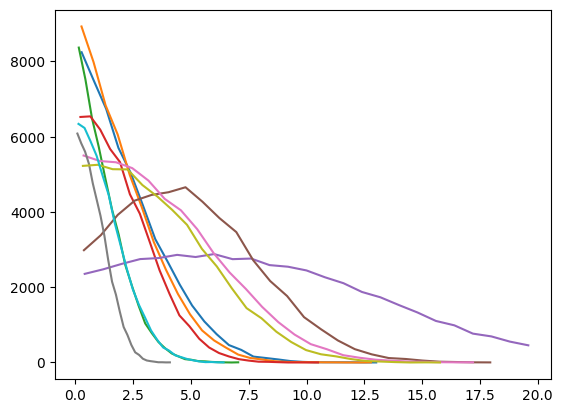

In [3]:
patch_ids = np.random.choice(253, 10, replace=False)
for id in patch_ids:
    hist = np.histogram(res["ParameterSets"]["strikeslipmain"][:,id], bins=25)
    bin_centres = (hist[1][:-1] + hist[1][1:]) / 2
    plt.plot(-bin_centres, hist[0])

### Three ways of choosing best solution

In [4]:
def soln(pset, method="median"):
    if method == "median":
        return np.median(pset, axis=0)
    elif method == "mean":
        return np.mean(pset, axis=0)
    elif method == "map":
        bins = 25
        maps = np.empty(pset.shape[1])
        for p in range(pset.shape[1]):
            hist = np.histogram(pset[:,p], bins=bins)
            bin_centres = (hist[1][:-1] + hist[1][1:]) / 2
            # if hist[1][-1] == 0: bin_centres[-1] = 0
            map = bin_centres[np.argmax(hist[0])]
            maps[p] = map
        return maps

In [5]:
method = "map"

faults[0].slip[:,0] = soln(res["ParameterSets"]["strikeslipmain"], method=method)
faults[0].slip[:,1] = soln(res["ParameterSets"]["dipslip"], method=method)[:253]
faults[1].slip[:,0] = soln(res["ParameterSets"]["strikeslipsecondary"], method=method)
faults[1].slip[:,1] = soln(res["ParameterSets"]["dipslip"], method=method)[253:]

for dataset in datasets:
    dataset.buildsynth(faults)

faults[0].slip[:,0] *= -1

### Visualise best solution (3D)

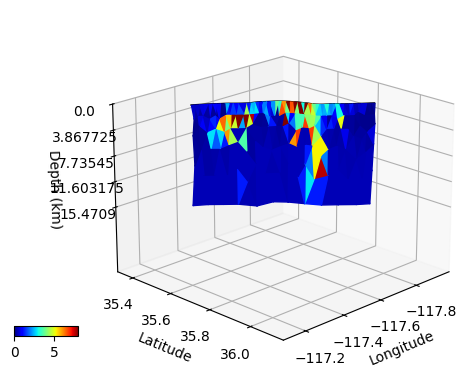

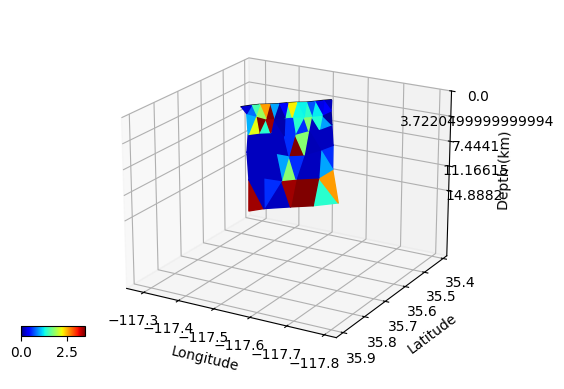

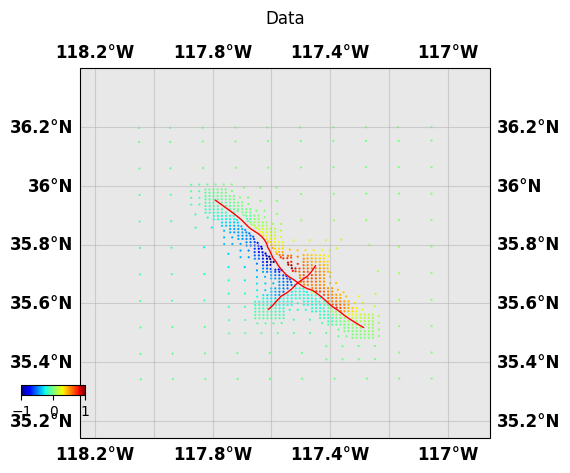

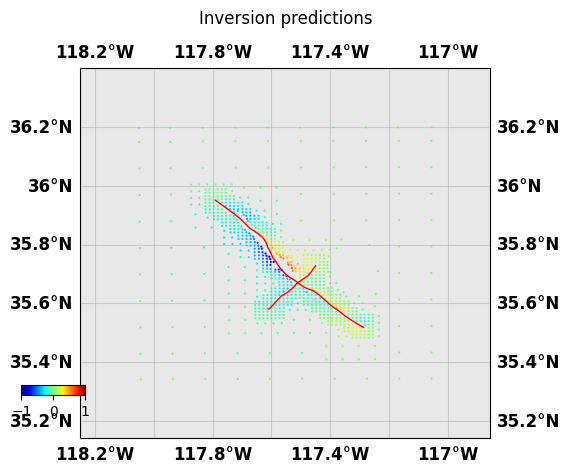

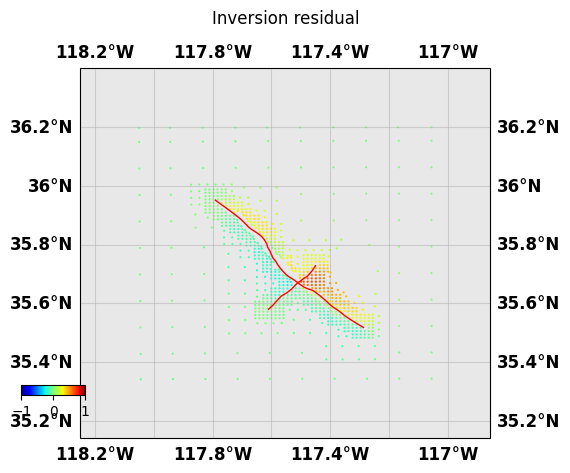

In [6]:
faults[0].plot(view=(20., 45.), slip="strikeslip", plot_on_2d=False, norm=(0., 8.))
faults[1].plot(view=(20., 120.), slip="strikeslip", plot_on_2d=False, norm=(0., 3.5))

datasets[0].plot(markersize=2.5, data="data", title="Data", norm=(-1., 1.), faults=faults)
datasets[0].plot(markersize=2.5, data="synth", title="Inversion predictions", norm=(-1., 1.), faults=faults)
datasets[0].plot(markersize=2.5, data="res", title="Inversion residual", norm=(-1., 1.), faults=faults)

## Théa utils

/Users/hintont/Dev/projects/Ridgecrest/scripts/utils.py:211: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cax.set_yticklabels(y_label_list)


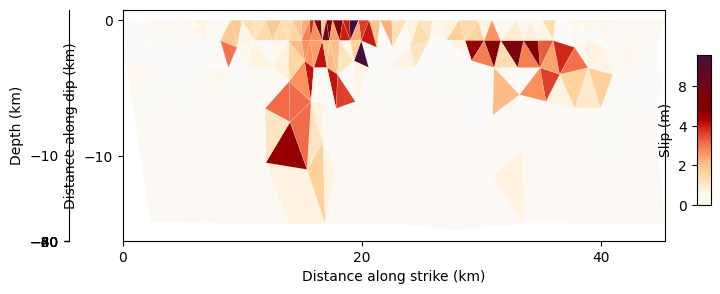

In [7]:
from utils import plotSlip2D

plotSlip2D(faults[0], save_path="../results/in10/slip_2d_main.pdf", slip='ss', valmax=8.)

center [np.float64(74.72795174077247), np.float64(-0.0)]
L 5.1569666666666665
<class 'IndexError'>
ERROR : list index out of range
<class 'IndexError'> utils.py 91


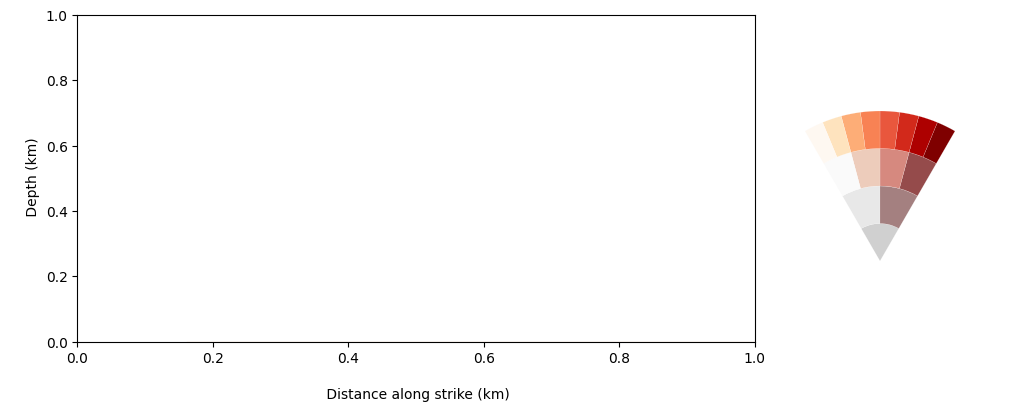

In [126]:
from utils import plotSlipBivariate
sigma = np.std(res["ParameterSets"]["strikeslipmain"], axis=0)


# plot slip bivariate
plotSlipBivariate(faults[0], sigma, save_path="../results/in10/slip_2d_bivariate.pdf", slip='strikeslip', valmax=8., sigmamax=4.)

In [45]:
faults[0].patch[0]

array([[ 470.70236908, 3932.94444648,   10.5       ],
       [ 473.28922707, 3931.02873121,    9.        ],
       [ 474.00399031, 3930.50536086,   15.        ]])